<a href="https://colab.research.google.com/github/noamesij366/ghana-flood-risk-protection-gap/blob/main/Flood_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
###Flood Risk and Insurance Protection Gap Project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data=pd.read_excel("/content/public_emdat_custom_request_2026-05-14_eeeb19f7-8964-4d53-b0ef-fe98f5735b4c.xlsx")

In [6]:
print(data)

           DisNo. Historic Classification Key Disaster Group  \
0   2010-0483-GHA       No    nat-hyd-flo-riv        Natural   
1   2008-0630-GHA       No    nat-hyd-flo-riv        Natural   
2   2002-0215-GHA       No    nat-hyd-flo-riv        Natural   
3   2015-0217-GHA       No    nat-hyd-flo-flo        Natural   
4   2013-0122-GHA       No    nat-hyd-flo-riv        Natural   
5   2023-0368-GHA       No    nat-hyd-flo-flo        Natural   
6   2011-0413-GHA       No    nat-hyd-flo-riv        Natural   
7   2020-0399-GHA       No    nat-hyd-flo-flo        Natural   
8   2017-0306-GHA       No    nat-hyd-flo-flo        Natural   
9   2001-0314-GHA       No    nat-hyd-flo-riv        Natural   
10  2011-0270-GHA       No    nat-hyd-flo-riv        Natural   
11  2022-0637-GHA       No    nat-hyd-flo-flo        Natural   
12  2019-0488-GHA       No    nat-hyd-flo-flo        Natural   
13  2021-0348-GHA       No    nat-hyd-flo-flo        Natural   
14  2007-0441-GHA       No    nat-hyd-fl

In [7]:
subtype_counts = data['Disaster Subtype'].value_counts()
print(subtype_counts)

Disaster Subtype
Riverine flood     12
Flood (General)    12
Flash flood         1
Name: count, dtype: int64


In [8]:
numofdeath=data['Total Deaths'].sum()
print(numofdeath)

325.0


In [9]:
totalaffected=data['Total Affected'].sum()
print(totalaffected)

2010330.0


In [10]:
#Annual flood counts
annual = data.groupby('Start Year').size().reindex(range(2001, 2024), fill_value=0)
print(annual)

Start Year
2001    1
2002    2
2003    0
2004    0
2005    0
2006    0
2007    1
2008    1
2009    2
2010    2
2011    2
2012    0
2013    1
2014    0
2015    1
2016    1
2017    1
2018    1
2019    2
2020    2
2021    2
2022    1
2023    2
dtype: int64


In [11]:
#Estimate lambda
lam = annual.mean()
var = annual.var(ddof=1)
print(lam,var)

1.0869565217391304 0.6284584980237152


In [32]:
#Chi-square goodness of fit
obs = [
    (annual == 0).sum(),
    (annual == 1).sum(),
    (annual >= 2).sum()
]
print(obs)



[np.int64(6), np.int64(9), np.int64(8)]


In [33]:
from scipy import stats
exp = [
    stats.poisson.pmf(0, lam) * 23,          # 7.757
    stats.poisson.pmf(1, lam) * 23,          # 8.431
    (1 - stats.poisson.cdf(1, lam)) * 23     # 6.812
]
print("Observed:", obs)
print("Expected:", exp)

Observed: [np.int64(6), np.int64(9), np.int64(8)]
Expected: [np.float64(7.756550360541048), np.float64(8.431033000588096), np.float64(6.812416638870853)]


In [34]:
chi2 = sum((o - e)**2 / e for o, e in zip(obs, exp))
df_chi = len(obs) - 1 - 1   # 3 groups - 1 - 1 estimated parameter = 1
p_val = 1 - stats.chi2.cdf(chi2, df_chi)
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", df_chi)
print("p-value:", p_val)

Chi-square statistic: 0.6432125014187693
Degrees of freedom: 1
p-value: 0.42254989236875506


In [35]:
#Probabilities
p0 = stats.poisson.pmf(0, lam)     # P(no flood)
p_at_least_1 = 1 - p0              # P(at least one flood)
print("Probability of no flood:", p0)
print("Probability of at least one flood:", p_at_least_1)

Probability of no flood: 0.33724132002352386
Probability of at least one flood: 0.6627586799764762


In [36]:
# Extract severity variable - drop missing values
severity = data['Total Affected'].dropna()

In [37]:
#Descriptive statistics
print(severity.mean())     # 91,379
print(severity.median())   # 16,163
print(severity.skew())     # 3.86

91378.63636363637
16163.0
3.86288330870541


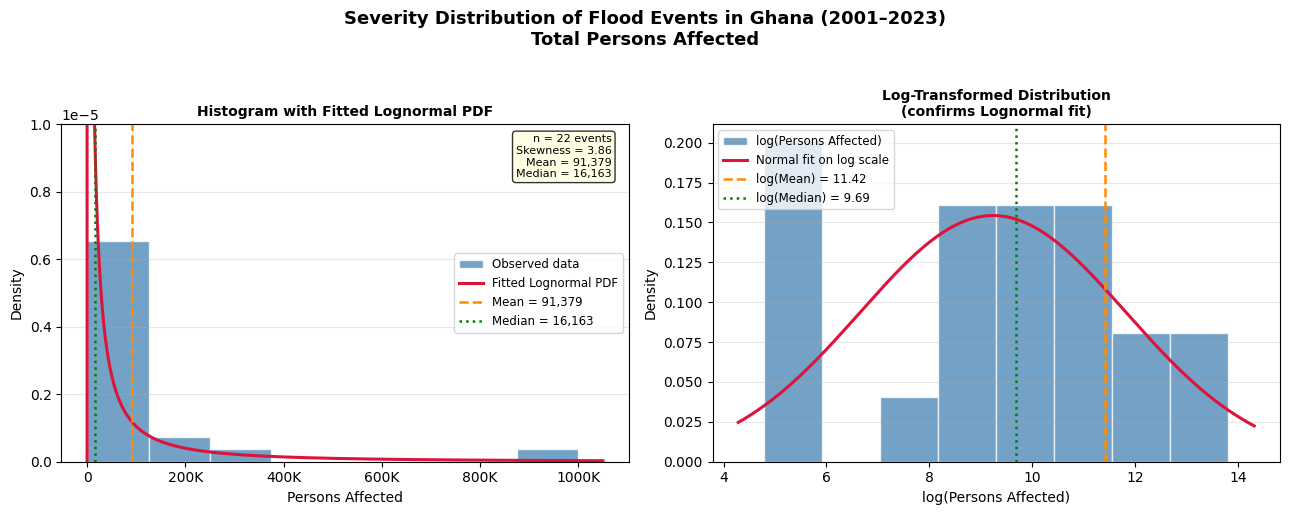

In [38]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ============================================
# STEP 1 - Load data
# ============================================
severity = data['Total Affected'].dropna()

# ============================================
# STEP 2 - Fit Lognormal distribution
# ============================================
shape, loc, scale = stats.lognorm.fit(severity, floc=0)
mu_ln = np.log(scale)
sigma_ln = shape

mean_val = severity.mean()
median_val = severity.median()

# ============================================
# STEP 3 - Build the plot
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Severity Distribution of Flood Events in Ghana (2001–2023)\nTotal Persons Affected",
             fontsize=13, fontweight='bold', y=1.02)

# --- LEFT PANEL: Histogram + fitted Lognormal PDF ---
ax1 = axes[0]
ax1.hist(severity, bins=8, density=True, color='steelblue',
         edgecolor='white', alpha=0.75, label='Observed data')
ax1.set_ylim(0, 0.00001)

x = np.linspace(0, severity.max() * 1.05, 2000)
pdf_ln = stats.lognorm.pdf(x, shape, loc=0, scale=scale)
ax1.plot(x, pdf_ln, color='crimson', linewidth=2.2, label='Fitted Lognormal PDF')

ax1.axvline(mean_val, color='darkorange', linewidth=1.8, linestyle='--',
            label=f'Mean = {mean_val:,.0f}')
ax1.axvline(median_val, color='green', linewidth=1.8, linestyle=':',
            label=f'Median = {median_val:,.0f}')

ax1.set_xlabel('Persons Affected', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.set_title('Histogram with Fitted Lognormal PDF', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8.5)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v/1000)}K' if v >= 1000 else str(int(v))))
ax1.grid(axis='y', alpha=0.3)

# --- RIGHT PANEL: Log-transformed data (confirms Lognormal shape) ---
ax2 = axes[1]
log_severity = np.log(severity)
ax2.hist(log_severity, bins=8, density=True, color='steelblue',
         edgecolor='white', alpha=0.75, label='log(Persons Affected)')

x_log = np.linspace(log_severity.min() - 0.5, log_severity.max() + 0.5, 300)
pdf_normal = stats.norm.pdf(x_log, mu_ln, sigma_ln)
ax2.plot(x_log, pdf_normal, color='crimson', linewidth=2.2, label='Normal fit on log scale')

ax2.axvline(np.log(mean_val), color='darkorange', linewidth=1.8, linestyle='--',
            label=f'log(Mean) = {np.log(mean_val):.2f}')
ax2.axvline(np.log(median_val), color='green', linewidth=1.8, linestyle=':',
            label=f'log(Median) = {np.log(median_val):.2f}')

ax2.set_xlabel('log(Persons Affected)', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.set_title('Log-Transformed Distribution\n(confirms Lognormal fit)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8.5)
ax2.grid(axis='y', alpha=0.3)

# --- Stats annotation box ---
textstr = (f'n = {len(severity)} events\n'
           f'Skewness = {severity.skew():.2f}\n'
           f'Mean = {mean_val:,.0f}\n'
           f'Median = {median_val:,.0f}')
ax1.text(0.97, 0.97, textstr, transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('severity_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

In [39]:
#Fit Lognormal distribution
shape, loc, scale = stats.lognorm.fit(severity, floc=0)
mu = np.log(scale)
sigma = shape
print(mu,sigma)

9.239014389056786 2.58560112774697


In [40]:
# Step 3 - Fit Pareto distribution
a, loc_p, scale_p = stats.pareto.fit(severity, floc=0)
alpha = a
print(a)

0.2246422358059552


In [41]:
#AIC for both distributions
loglik_ln = np.sum(stats.lognorm.logpdf(severity, shape, loc=0, scale=scale))
aic_ln = 2*2 - 2*loglik_ln

loglik_pa = np.sum(stats.pareto.logpdf(severity, a, loc=0, scale=scale_p))
aic_pa = 2*2 - 2*loglik_pa

print("AIC for Lognormal:", aic_ln)
print("AIC for Pareto:", aic_pa)

AIC for Lognormal: 514.7480817019027
AIC for Pareto: 520.2194661540887


In [42]:
#return Period in 5, 10, 15 amd 20 years
import numpy as np
from scipy import stats

# Parameters already fitted earlier (MLE)
shape = 2.586      # sigma
scale = np.exp(9.239)   # = e^mu

return_periods = [5, 10, 25, 50]

print("Return Period | Estimated Persons Affected")
for T in return_periods:
    p = 1 - 1/T
    x = stats.lognorm.ppf(p, shape, loc=0, scale=scale)
    print(f"1-in-{T} years : {x:,.0f}")

Return Period | Estimated Persons Affected
1-in-5 years : 90,711
1-in-10 years : 282,969
1-in-25 years : 951,956
1-in-50 years : 2,084,406
